In [7]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random
import collections
import pandas as pd
import math

In [19]:
starting_pop = 1
repro_chance = 0.2
death_chance = 0.1

n_periods = 50
r_runs = 100000

In [20]:
def discrete_pop(starting_pop, repro_chance, death_chance, end_time):
    """ Exponential population growth model for discrete breeding season"""

    r = 1 + (repro_chance - death_chance)
    return pd.Series([r**t*starting_pop for t in range(end_time + 1)])

def continuous_pop(starting_pop, repro_chance, death_chance, end_time):
    """ Exponential population growth model for continuous breeding season"""

    r = repro_chance - death_chance
    return pd.Series([starting_pop * math.exp(r*t) for t in range(end_time + 1)])


In [21]:
pred_disc = discrete_pop(starting_pop, repro_chance, death_chance, n_periods)
pred_disc.iloc[-1]

117.39085287969579

In [22]:
pred_cont = continuous_pop(starting_pop, repro_chance, death_chance, n_periods)
pred_cont.iloc[-1]

148.4131591025766

In [23]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, starting_pop, repro_chance, death_chance):
        self.repro_chance = repro_chance
        self.death_chance = death_chance
        self.starting_pop = starting_pop

        self.population = [entity() for p in range(0, starting_pop)]
        self.history = [starting_pop]
        self.mortuary = collections.Counter()

    def __call__(self):

        # Simulate period
        survive, expire, births = [], [], []
        # First determine which entities expired by end of previous period.
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e.period) 
            else:
                survive.append(e())
                # Determine if the entity reproduced by end of current period.
                if trial(self.repro_chance):
                    births.append(entity())            

        # Finally, update attributes
        self.population = survive + births
        self.mortuary.update(expire)
        self.history.append(len(self.population))

103.95614756832485
pred_disc 117.39085287969579
pred_cont 148.4131591025766


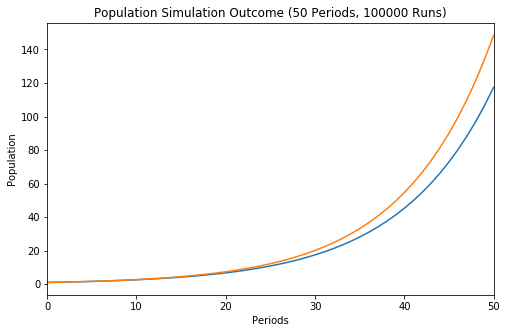

In [24]:
def run_sim(starting_pop, repro_chance, death_chance, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )

    # Run simulation n times with r repeats.
    last = []
    for r in range(r_runs):
        env = environment(starting_pop, repro_chance, death_chance)
        for period in range(0, n_periods):
            env()
        last.append(env.history[-1])
        # ax.plot(env.history, color=[.5, .5, .5, .5])

    ax.plot(pred_disc)
    ax.plot(pred_cont)
    last = [x for x in last if x > 0]
    print(sum(last)/len(last))
    print("pred_disc", pred_disc.iloc[-1])
    print("pred_cont", pred_cont.iloc[-1])


# Run the simulation
run_sim(starting_pop, repro_chance, death_chance, n_periods, r_runs)

In [91]:
1*math.exp(.1*10)

2.718281828459045

In [92]:
last

NameError: name 'last' is not defined